# MOGA-Phonons Experiment Dataframe Explorer

This notebook loads a pickled dataframe produced by `build_experiment_dataframe_updated.py` and provides quick visual diagnostics for a MOGA-Phonons experiment.

Designed for files such as:

```text
dataframes/dataframe000009.pkl
dataframes/dataframe000009.summary.json
```


## 1. Imports and paths

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes this notebook is run from the repo root.
repo_root = Path.cwd()

experiment_id = "experiment000009"
df_path = repo_root / "dataframes" / "dataframe000009.pkl"
summary_path = repo_root / "dataframes" / "dataframe000009.summary.json"

print("Repo root:", repo_root)
print("Dataframe:", df_path)
print("Summary:", summary_path)


Repo root: /Users/jamunoz/Documents/GitHub/MOGA-Phonons
Dataframe: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/dataframe000009.pkl
Summary: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/dataframe000009.summary.json


## 2. Load dataframe and summary

In [2]:
df = pd.read_pickle(df_path)

if summary_path.exists():
    with open(summary_path, "r") as f:
        summary = json.load(f)
else:
    summary = {}

print("Rows:", len(df))
print("Columns:", len(df.columns))
display(pd.DataFrame(summary.items(), columns=["field", "value"]))
display(df.head())


Rows: 45000
Columns: 32


,field,value
0,n_simulations_in_experiment,42
1,n_rows,45000
2,n_missing_simulation_dirs,0
3,n_missing_phonon_dirs,0
4,n_simulations_with_no_yaml,0
5,n_load_errors,0
6,missing_simulation_dirs,[]
7,missing_phonon_dirs,[]
8,simulations_with_no_yaml,[]
9,load_errors,[]


,simulation,generation,solution_index,rank,mass,a_val,alpha0,alpha1,beta1,alpha2,...,distances,qpoints,frequencies,simulation_path,phonon_root,generation_dir,band_yaml_path,source,sort_by,sort_score
0,simulation000378,1,32,0,50.0,2.0,5.678658,-0.213290,0.458474,-1.848822,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[3.6021381144725493, 3.6021381144725497, 3.60...",simulations/simulation000378,simulations/simulation000378/phonon_generations,simulations/simulation000378/phonon_generation...,simulations/simulation000378/phonon_generation...,population,fitness_norm,1.135541
1,simulation000378,1,1,1,50.0,2.0,9.232152,-1.195974,-0.801361,0.306837,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[5.714723665746552, 5.714723665746552, 5.7147...",simulations/simulation000378,simulations/simulation000378/phonon_generations,simulations/simulation000378/phonon_generation...,simulations/simulation000378/phonon_generation...,population,fitness_norm,1.109111
2,simulation000378,1,68,2,50.0,2.0,9.232152,-1.195974,-0.801361,0.568529,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[3.7258525035296133, 3.7258525035296133, 3.72...",simulations/simulation000378,simulations/simulation000378/phonon_generations,simulations/simulation000378/phonon_generation...,simulations/simulation000378/phonon_generation...,population,fitness_norm,1.086500
3,simulation000378,1,3,3,50.0,2.0,8.430222,0.098187,-0.447320,-0.509221,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[3.2314153085222213, 3.2314153085222213, 3.23...",simulations/simulation000378,simulations/simulation000378/phonon_generations,simulations/simulation000378/phonon_generation...,simulations/simulation000378/phonon_generation...,population,fitness_norm,1.069049
4,simulation000378,1,30,4,50.0,2.0,9.638393,-1.043644,-0.495353,1.233530,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[4.479430816583797, 4.479430816583797, 4.4794...",simulations/simulation000378,simulations/simulation000378/phonon_generations,simulations/simulation000378/phonon_generation...,simulations/simulation000378/phonon_generation...,population,fitness_norm,1.051931


## 3. Inspect dataframe schema

In [3]:
schema_rows = []
for c in df.columns:
    s = df[c]
    try:
        n_unique = s.nunique(dropna=True)
    except TypeError:
        n_unique = None
    schema_rows.append({
        "column": c,
        "dtype": str(s.dtype),
        "non_null": int(s.notna().sum()),
        "n_unique": n_unique,
    })

schema = pd.DataFrame(schema_rows)
display(schema)


,column,dtype,non_null,n_unique
0,simulation,object,45000,42.0
1,generation,int64,45000,300.0
2,solution_index,int64,45000,100.0
3,rank,int64,45000,5.0
4,mass,float64,45000,6.0
5,a_val,float64,45000,7.0
6,alpha0,float64,45000,7186.0
7,alpha1,float64,45000,3298.0
8,beta1,float64,45000,13349.0
9,alpha2,float64,45000,10208.0


## 4. Basic experiment coverage

This checks how many rows are available per simulation and per generation.


count    300.00000
mean     150.00000
std       84.99459
min       30.00000
25%       30.00000
50%      210.00000
75%      210.00000
max      210.00000
dtype: float64

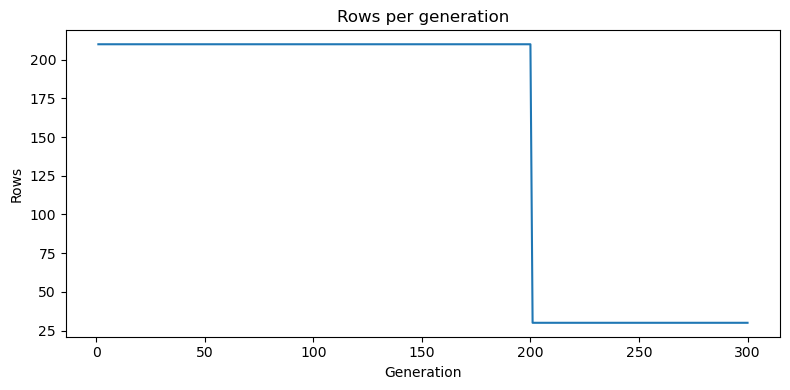

In [4]:
if "simulation_id" in df.columns:
    counts_by_sim = df.groupby("simulation_id").size().sort_index()
    display(counts_by_sim.describe())
    display(counts_by_sim.head())

    plt.figure(figsize=(10, 4))
    counts_by_sim.plot(kind="bar")
    plt.ylabel("Rows")
    plt.xlabel("Simulation")
    plt.title("Rows per simulation")
    plt.tight_layout()
    plt.show()

if "generation" in df.columns:
    counts_by_gen = df.groupby("generation").size().sort_index()
    display(counts_by_gen.describe())

    plt.figure(figsize=(8, 4))
    counts_by_gen.plot()
    plt.ylabel("Rows")
    plt.xlabel("Generation")
    plt.title("Rows per generation")
    plt.tight_layout()
    plt.show()


## 5. Stability overview

The builder adds `min_frequency`, `num_imaginary`, and `is_stable` when possible. These are useful first-pass metrics.


,min_frequency,max_frequency,num_imaginary,is_stable
count,45000.000000,45000.000000,45000.000000,45000
unique,NaN,NaN,NaN,2
top,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,24651
mean,-0.163148,6.788817,85.535956,NaN
std,1.166789,1.226707,132.862702,NaN
min,-7.183876,2.574149,0.000000,NaN
25%,-0.740645,5.950654,0.000000,NaN
50%,-0.037371,6.714748,11.000000,NaN
75%,0.467179,7.582401,131.000000,NaN


is_stable
False    24651
True     20349
Name: count, dtype: int64

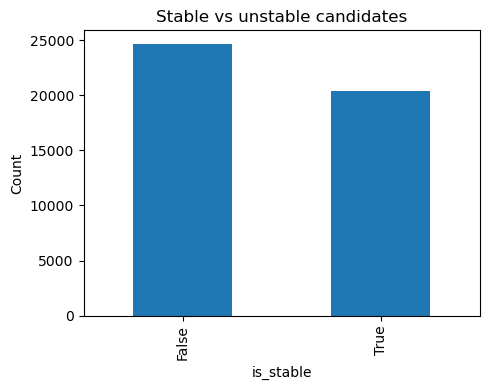

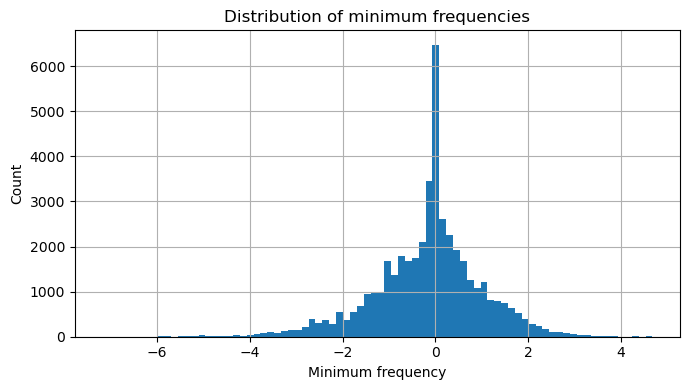

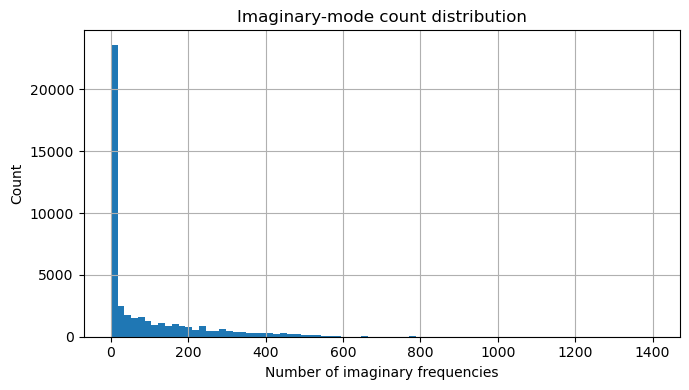

In [5]:
stability_cols = [c for c in ["min_frequency", "max_frequency", "num_imaginary", "is_stable"] if c in df.columns]
display(df[stability_cols].describe(include="all") if stability_cols else "No stability columns found.")

if "is_stable" in df.columns:
    stable_counts = df["is_stable"].value_counts(dropna=False)
    display(stable_counts)
    plt.figure(figsize=(5, 4))
    stable_counts.plot(kind="bar")
    plt.ylabel("Count")
    plt.title("Stable vs unstable candidates")
    plt.tight_layout()
    plt.show()

if "min_frequency" in df.columns:
    plt.figure(figsize=(7, 4))
    df["min_frequency"].dropna().hist(bins=80)
    plt.xlabel("Minimum frequency")
    plt.ylabel("Count")
    plt.title("Distribution of minimum frequencies")
    plt.tight_layout()
    plt.show()

if "num_imaginary" in df.columns:
    plt.figure(figsize=(7, 4))
    df["num_imaginary"].dropna().hist(bins=80)
    plt.xlabel("Number of imaginary frequencies")
    plt.ylabel("Count")
    plt.title("Imaginary-mode count distribution")
    plt.tight_layout()
    plt.show()


## 6. Fitness distributions

,fitness1,fitness2,fitness3,fitness_norm
count,45000.000000,45000.000000,45000.000000,45000.000000
mean,0.953548,0.818647,0.637500,1.458281
std,0.196121,0.221690,0.270933,0.142368
min,0.001686,0.075383,0.162893,1.018266
25%,1.000000,0.703063,0.377561,1.370494
50%,1.000000,0.920212,0.626198,1.446203
75%,1.000000,0.992114,0.929786,1.551999
max,1.000000,1.000000,1.000000,1.724438


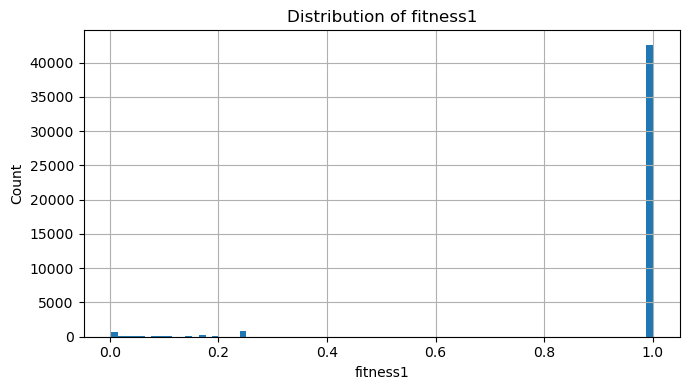

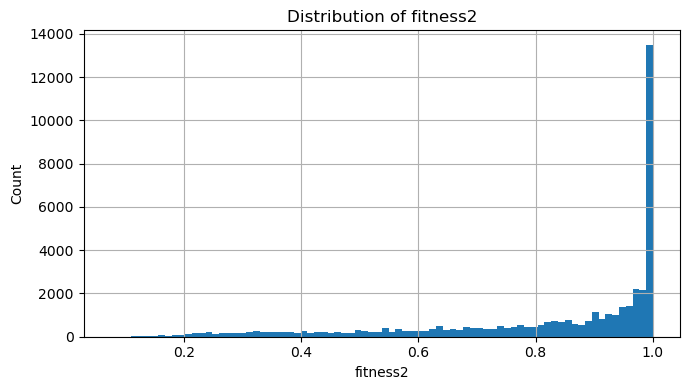

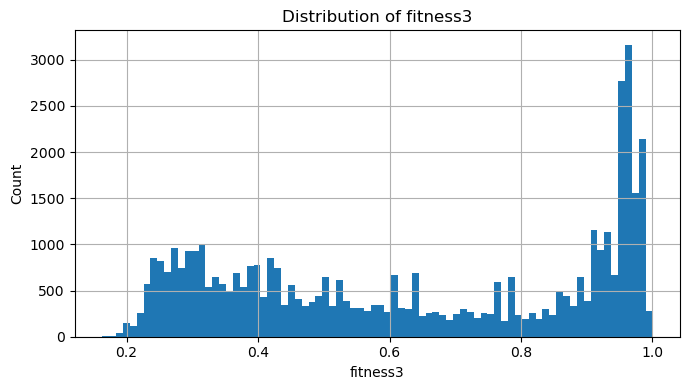

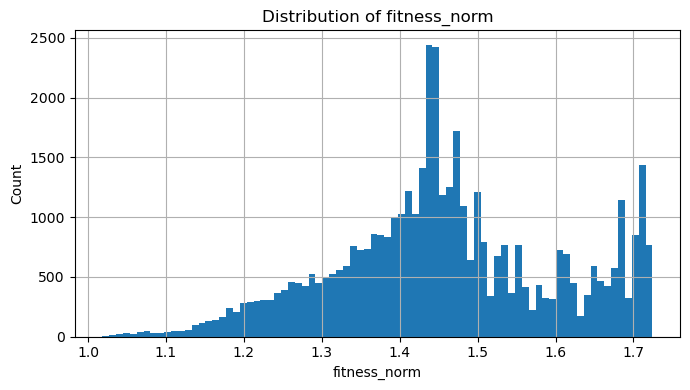

In [6]:
fitness_cols = [c for c in ["fitness1", "fitness2", "fitness3", "fitness_norm"] if c in df.columns]
display(df[fitness_cols].describe() if fitness_cols else "No fitness columns found.")

for col in fitness_cols:
    plt.figure(figsize=(7, 4))
    df[col].dropna().hist(bins=80)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


## 7. Fitness evolution by generation

This shows whether the top-k candidates improve across generations.


,mean,max,min,std,count
generation,,,,,
1,1.136926,1.583155,1.018266,0.103776,210
2,1.196792,1.583155,1.031019,0.112994,210
3,1.249690,1.583155,1.047331,0.109682,210
4,1.269852,1.583155,1.045796,0.118772,210
5,1.295144,1.656176,1.061805,0.109277,210


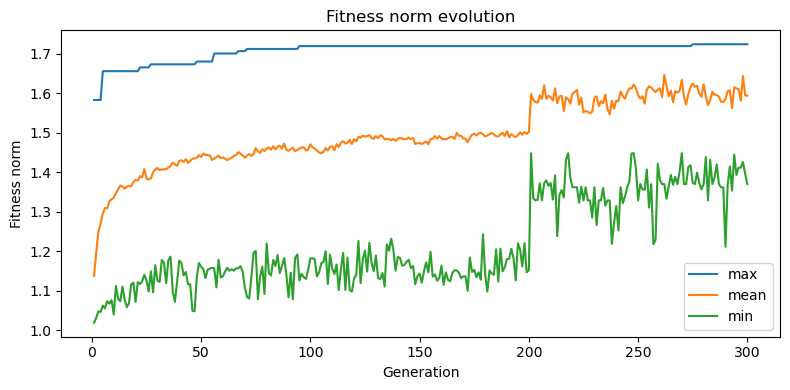

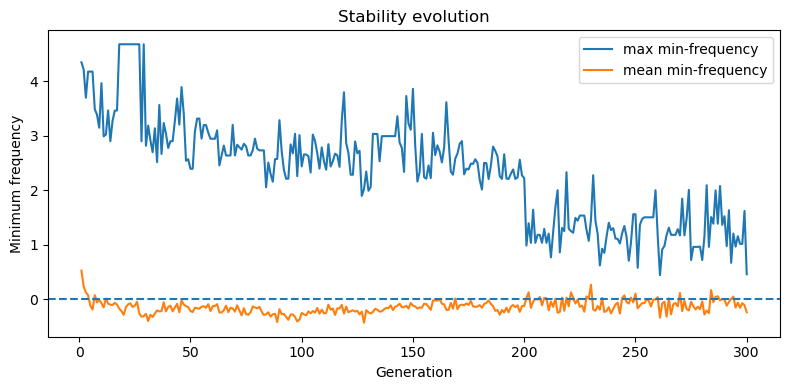

In [7]:
if "generation" in df.columns and "fitness_norm" in df.columns:
    gen_stats = df.groupby("generation")["fitness_norm"].agg(["mean", "max", "min", "std", "count"])
    display(gen_stats.head())

    plt.figure(figsize=(8, 4))
    gen_stats["max"].plot(label="max")
    gen_stats["mean"].plot(label="mean")
    gen_stats["min"].plot(label="min")
    plt.xlabel("Generation")
    plt.ylabel("Fitness norm")
    plt.title("Fitness norm evolution")
    plt.legend()
    plt.tight_layout()
    plt.show()

if "generation" in df.columns and "min_frequency" in df.columns:
    gen_minfreq = df.groupby("generation")["min_frequency"].agg(["mean", "max", "min"])
    plt.figure(figsize=(8, 4))
    gen_minfreq["max"].plot(label="max min-frequency")
    gen_minfreq["mean"].plot(label="mean min-frequency")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Generation")
    plt.ylabel("Minimum frequency")
    plt.title("Stability evolution")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 8. Parameter sweep maps

These plots summarize behavior over lattice parameter and mass, if `a_val` and `mass` or `atomic_masses` are available.


a_val,2.0,2.2,2.4,2.6,2.8,3.0,3.2
mass,,,,,,,
50.0,1.663590,1.680751,1.714192,1.690718,1.693325,1.702062,1.645009
60.0,1.642191,1.664320,1.646326,1.611514,1.626439,1.597286,1.697375
70.0,1.679187,1.701015,1.708958,1.701791,1.684049,1.646911,1.711438
80.0,1.667622,1.711481,1.678689,1.664809,1.703703,1.698256,1.655677
90.0,1.676357,1.678654,1.682902,1.706977,1.664017,1.606874,1.687345
100.0,1.628469,1.715615,1.708800,1.712533,1.716647,1.693840,1.724438


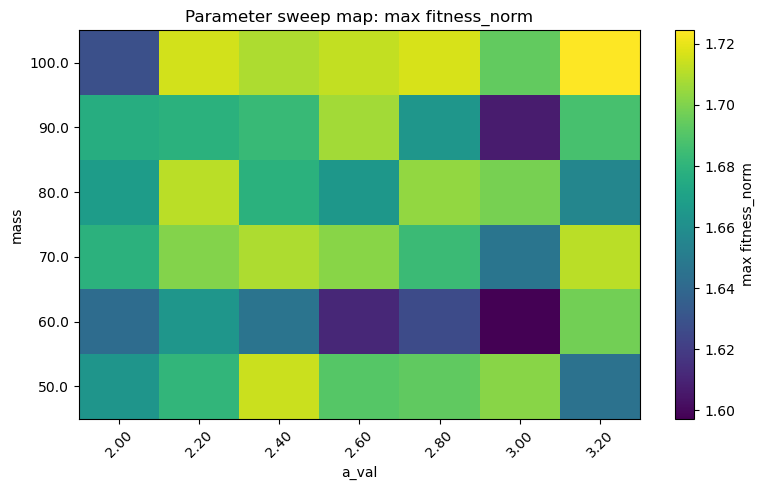

a_val,2.0,2.2,2.4,2.6,2.8,3.0,3.2
mass,,,,,,,
50.0,0.315,0.591000,0.535,0.329000,0.364000,0.628000,0.349000
60.0,0.519,0.461000,0.677,0.433000,0.385000,0.466000,0.256000
70.0,0.443,0.479000,0.408,0.275000,0.558000,0.453000,0.293000
80.0,0.366,0.443000,0.494,0.486000,0.389000,0.197000,0.495000
90.0,0.474,0.362000,0.643,0.327000,0.398000,0.512000,0.369000
100.0,0.538,0.518667,0.416,0.738667,0.450667,0.345333,0.623333


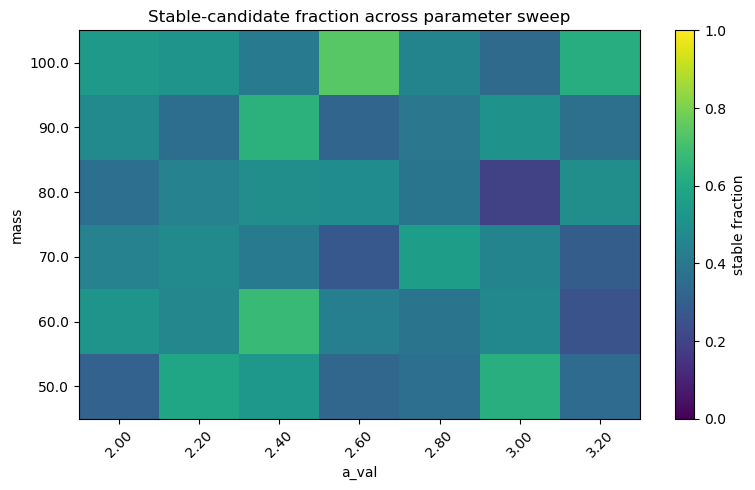

In [8]:
df_plot = df.copy()

if "mass" not in df_plot.columns and "atomic_masses" in df_plot.columns:
    def first_mass(x):
        if isinstance(x, (list, tuple, np.ndarray)):
            return float(x[0])
        return float(x)
    df_plot["mass"] = df_plot["atomic_masses"].map(first_mass)

metric = "fitness_norm" if "fitness_norm" in df_plot.columns else None
if metric and "a_val" in df_plot.columns and "mass" in df_plot.columns:
    pivot = df_plot.groupby(["mass", "a_val"])[metric].max().unstack("a_val")
    display(pivot)

    plt.figure(figsize=(8, 5))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.colorbar(label=f"max {metric}")
    plt.xticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns], rotation=45)
    plt.yticks(range(len(pivot.index)), [f"{x:.1f}" for x in pivot.index])
    plt.xlabel("a_val")
    plt.ylabel("mass")
    plt.title(f"Parameter sweep map: max {metric}")
    plt.tight_layout()
    plt.show()

if "is_stable" in df_plot.columns and "a_val" in df_plot.columns and "mass" in df_plot.columns:
    stable_fraction = df_plot.groupby(["mass", "a_val"])["is_stable"].mean().unstack("a_val")
    display(stable_fraction)

    plt.figure(figsize=(8, 5))
    plt.imshow(stable_fraction.values, aspect="auto", origin="lower", vmin=0, vmax=1)
    plt.colorbar(label="stable fraction")
    plt.xticks(range(len(stable_fraction.columns)), [f"{x:.2f}" for x in stable_fraction.columns], rotation=45)
    plt.yticks(range(len(stable_fraction.index)), [f"{x:.1f}" for x in stable_fraction.index])
    plt.xlabel("a_val")
    plt.ylabel("mass")
    plt.title("Stable-candidate fraction across parameter sweep")
    plt.tight_layout()
    plt.show()


## 9. Force-constant relationships

Scatter plots of the reduced BvK parameters and their relation to fitness/stability.


,alpha0,alpha1,beta1,alpha2,beta2
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,7.399276,-0.460439,-0.017545,-0.613316,-0.603847
std,1.629760,0.243565,0.595646,0.717357,0.530662
min,1.076915,-1.523532,-1.996133,-1.999904,-1.996057
25%,6.415778,-0.653091,-0.479984,-1.145380,-0.995541
50%,7.480015,-0.450487,-0.018663,-0.489766,-0.622318
75%,8.768752,-0.295346,0.459102,-0.022398,-0.155605
max,9.997863,0.485055,1.992093,1.998419,1.948683


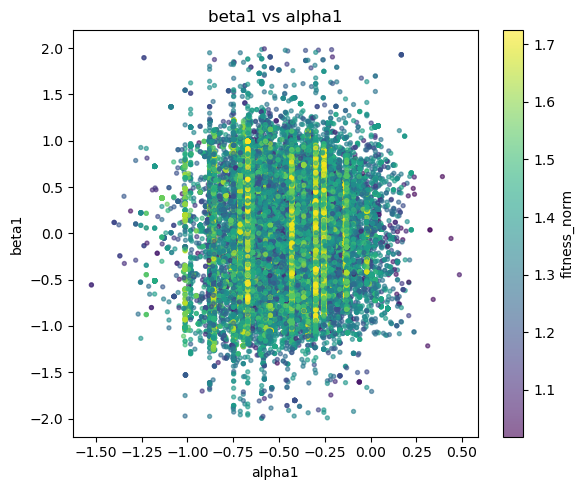

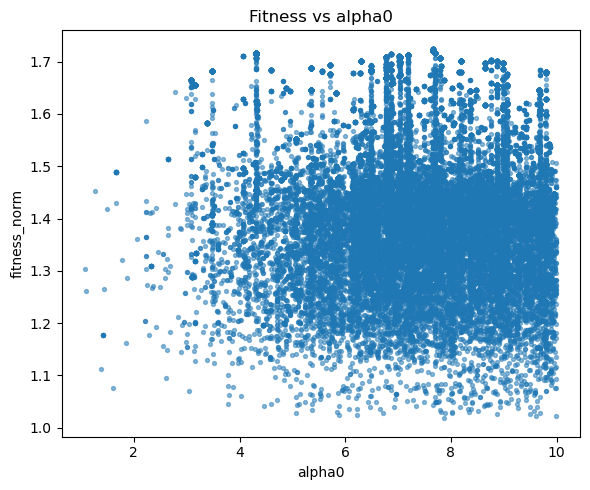

In [9]:
fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]
display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

if len(fc_cols) >= 2:
    color_col = "fitness_norm" if "fitness_norm" in df.columns else None
    xcol, ycol = "alpha1", "beta1"
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6, 5))
        if color_col:
            sc = plt.scatter(df[xcol], df[ycol], c=df[color_col], s=8, alpha=0.6)
            plt.colorbar(sc, label=color_col)
        else:
            plt.scatter(df[xcol], df[ycol], s=8, alpha=0.6)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.tight_layout()
        plt.show()

if "alpha0" in df.columns and "fitness_norm" in df.columns:
    plt.figure(figsize=(6, 5))
    plt.scatter(df["alpha0"], df["fitness_norm"], s=8, alpha=0.5)
    plt.xlabel("alpha0")
    plt.ylabel("fitness_norm")
    plt.title("Fitness vs alpha0")
    plt.tight_layout()
    plt.show()


## 10. Top candidates

This table lists the highest-ranking candidates according to `fitness_norm`, with stable candidates prioritized if available.


In [10]:
preferred_cols = [
    "simulation_id", "generation", "solution_index", "rank",
    "a_val", "mass",
    "alpha0", "alpha1", "beta1", "alpha2", "beta2",
    "fitness1", "fitness2", "fitness3", "fitness_norm",
    "min_frequency", "num_imaginary", "is_stable",
    "yaml_path", "plot_path"
]
cols = [c for c in preferred_cols if c in df_plot.columns]

sort_cols = []
ascending = []
if "is_stable" in df_plot.columns:
    sort_cols.append("is_stable")
    ascending.append(False)
if "fitness_norm" in df_plot.columns:
    sort_cols.append("fitness_norm")
    ascending.append(False)
elif "min_frequency" in df_plot.columns:
    sort_cols.append("min_frequency")
    ascending.append(False)

top = df_plot.sort_values(sort_cols, ascending=ascending).head(25) if sort_cols else df_plot.head(25)
display(top[cols])


,generation,solution_index,rank,a_val,mass,alpha0,alpha1,beta1,alpha2,beta2,fitness1,fitness2,fitness3,fitness_norm,min_frequency,num_imaginary,is_stable
44870,275,8,0,3.2,100.0,7.652255,-0.670183,-0.547571,-1.14538,0.000309,1.0,0.998735,0.988035,1.724438,0.056367,0,True
44875,276,1,0,3.2,100.0,7.652255,-0.670183,-0.547571,-1.14538,0.000309,1.0,0.998735,0.988035,1.724438,0.056367,0,True
44880,277,1,0,3.2,100.0,7.652255,-0.670183,-0.547571,-1.14538,0.000309,1.0,0.998735,0.988035,1.724438,0.056367,0,True
44885,278,1,0,3.2,100.0,7.652255,-0.670183,-0.547571,-1.14538,0.000309,1.0,0.998735,0.988035,1.724438,0.056367,0,True
44890,279,1,0,3.2,100.0,7.652255,-0.670183,-0.547571,-1.14538,0.000309,1.0,0.998735,0.988035,1.724438,0.056367,0,True
44895,280,1,0,3.2,100.0,7.652255,-0.670183,-0.547571,-1.14538,0.000309,1.0,0.998735,0.988035,1.724438,0.056367,0,True
44900,281,1,0,3.2,100.0,7.652255,-0.670183,-0.547571,-1.14538,0.000309,1.0,0.998735,0.988035,1.724438,0.056367,0,True
44905,282,1,0,3.2,100.0,7.652255,-0.670183,-0.547571,-1.14538,0.000309,1.0,0.998735,0.988035,1.724438,0.056367,0,True
44910,283,1,0,3.2,100.0,7.652255,-0.670183,-0.547571,-1.14538,0.000309,1.0,0.998735,0.988035,1.724438,0.056367,0,True
44915,284,1,0,3.2,100.0,7.652255,-0.670183,-0.547571,-1.14538,0.000309,1.0,0.998735,0.988035,1.724438,0.056367,0,True


## 11. Save filtered subsets

Useful for making small curated datasets for plotting, manuscript figures, or Zenodo releases.


In [11]:
# Best row by fitness_norm for each (a_val, mass)
idx = df.groupby(["a_val", "mass"])["fitness_norm"].idxmax()

best_df = (
    df.loc[idx]
    .sort_values(["a_val", "mass"])
    .reset_index(drop=True)
)

best_df.head()

,simulation,generation,solution_index,rank,mass,a_val,alpha0,alpha1,beta1,alpha2,...,distances,qpoints,frequencies,simulation_path,phonon_root,generation_dir,band_yaml_path,source,sort_by,sort_score
0,simulation000378,141,67,0,50.0,2.0,4.826217,-0.184527,-0.493338,-0.006424,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-0.21549020106254857, -0.21549020106254355, ...",simulations/simulation000378,simulations/simulation000378/phonon_generations,simulations/simulation000378/phonon_generation...,simulations/simulation000378/phonon_generation...,population,fitness_norm,1.663590
1,simulation000385,159,80,0,60.0,2.0,6.811195,-0.432831,-0.214562,-1.670298,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.21013081347834844, 0.21013081347835705, 0....",simulations/simulation000385,simulations/simulation000385/phonon_generations,simulations/simulation000385/phonon_generation...,simulations/simulation000385/phonon_generation...,population,fitness_norm,1.642191
2,simulation000392,173,9,0,70.0,2.0,8.160787,-0.594081,-0.583347,-0.005694,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-0.1763764340681038, -0.1763764340681038, -0...",simulations/simulation000392,simulations/simulation000392/phonon_generations,simulations/simulation000392/phonon_generation...,simulations/simulation000392/phonon_generation...,population,fitness_norm,1.679187
3,simulation000399,46,92,0,80.0,2.0,6.883069,-0.370475,-0.152970,-0.013871,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-0.27386181407999305, -0.27386181407999305, ...",simulations/simulation000399,simulations/simulation000399/phonon_generations,simulations/simulation000399/phonon_generation...,simulations/simulation000399/phonon_generation...,population,fitness_norm,1.667622
4,simulation000406,124,11,0,90.0,2.0,9.058365,-0.694351,0.864398,-1.751425,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-0.39966119376940124, -0.39966119376940124, ...",simulations/simulation000406,simulations/simulation000406/phonon_generations,simulations/simulation000406/phonon_generation...,simulations/simulation000406/phonon_generation...,population,fitness_norm,1.676357


In [12]:
best_df[
    [
        "simulation",
        "generation",
        "a_val",
        "mass",
        "alpha0",
        "alpha1",
        "beta1",
        "alpha2",
        "beta2",
        "fitness_norm",
        "fitness1",
        "fitness2",
        "fitness3",
        "min_frequency",
        "num_imaginary",
    ]
]

,simulation,generation,a_val,mass,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm,fitness1,fitness2,fitness3,min_frequency,num_imaginary
0,simulation000378,141,2.0,50.0,4.826217,-0.184527,-0.493338,-0.006424,-0.836661,1.663590,1.0,0.990601,0.886703,-0.215490,56
1,simulation000385,159,2.0,60.0,6.811195,-0.432831,-0.214562,-1.670298,0.000719,1.642191,1.0,0.989287,0.847410,0.210131,0
2,simulation000392,173,2.0,70.0,8.160787,-0.594081,-0.583347,-0.005694,-0.851417,1.679187,1.0,0.991159,0.915026,-0.176376,36
3,simulation000399,46,2.0,80.0,6.883069,-0.370475,-0.152970,-0.013871,-0.979028,1.667622,1.0,0.976006,0.910151,-0.273862,60
4,simulation000406,124,2.0,90.0,9.058365,-0.694351,0.864398,-1.751425,-0.014882,1.676357,1.0,0.944448,0.958222,-0.399661,96
5,simulation000413,117,2.0,100.0,5.705755,-0.555647,0.118624,0.049416,-0.314156,1.628469,1.0,0.906792,0.910846,0.501144,0
6,simulation000379,160,2.2,50.0,9.800142,-0.746939,0.681787,-0.000392,-0.955652,1.680751,1.0,0.998762,0.909614,0.077853,0
7,simulation000386,171,2.2,60.0,7.126405,-0.878359,0.279217,-0.048313,-0.006360,1.664320,1.0,0.977964,0.901969,-0.303007,61
8,simulation000393,56,2.2,70.0,8.184646,-0.416755,0.757282,0.005584,-1.212524,1.701015,1.0,0.988453,0.957294,0.202372,0
9,simulation000400,141,2.2,80.0,7.009629,-0.607401,0.862047,-0.001505,-0.537506,1.711481,1.0,0.997390,0.966634,-0.831825,120


In [13]:
df_valid = df.dropna(subset=["fitness_norm"])

idx = df_valid.groupby(["a_val", "mass"])["fitness_norm"].idxmax()

best_df = (
    df_valid.loc[idx]
    .sort_values(["a_val", "mass"])
    .reset_index(drop=True)
)

In [14]:
from pathlib import Path

REPO_ROOT = Path.cwd()

best_df = best_df.copy()

best_df["dispersion_path"] = best_df["generation_dir"].apply(
    lambda p: REPO_ROOT / p / "dispersion.png"
)

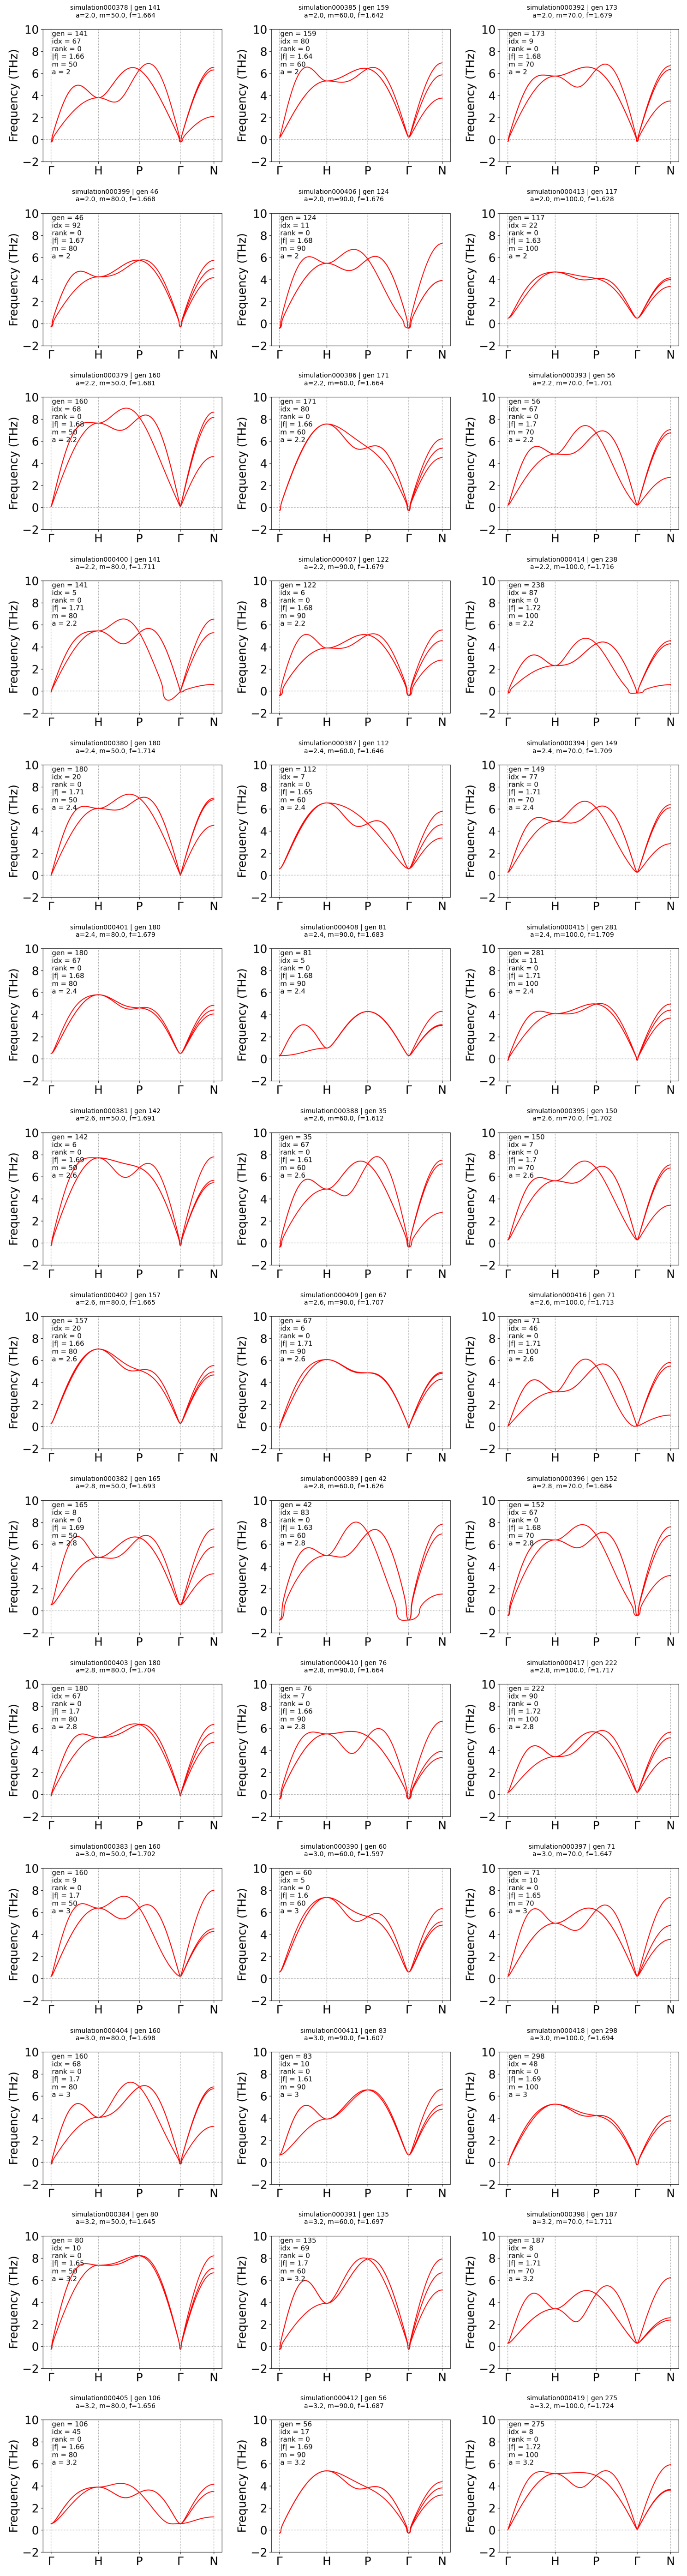

In [15]:
import math

n = len(best_df)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.ravel()

for ax, (_, row) in zip(axes, best_df.iterrows()):
    img = plt.imread(row["dispersion_path"])
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"{row['simulation']} | gen {row['generation']}\n"
        f"a={row['a_val']}, m={row['mass']}, "
        f"f={row['fitness_norm']:.3f}",
        fontsize=10,
    )

for ax in axes[len(best_df):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
output_dir = repo_root / "dataframes" / "subsets"
output_dir.mkdir(parents=True, exist_ok=True)

if "is_stable" in df_plot.columns:
    stable_df = df_plot[df_plot["is_stable"] == True].copy()
    stable_path = output_dir / f"{experiment_id}_stable_candidates.pkl"
    stable_df.to_pickle(stable_path)
    print("Saved stable candidates:", stable_path, "rows =", len(stable_df))

if "fitness_norm" in df_plot.columns:
    top_path = output_dir / f"{experiment_id}_top100_by_fitness_norm.pkl"
    df_plot.sort_values("fitness_norm", ascending=False).head(100).to_pickle(top_path)
    print("Saved top 100:", top_path)


Saved stable candidates: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/subsets/experiment000009_stable_candidates.pkl rows = 20349
Saved top 100: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/subsets/experiment000009_top100_by_fitness_norm.pkl


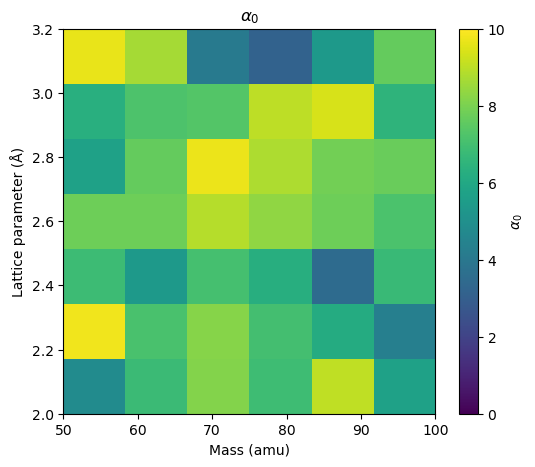

In [17]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="alpha0",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=0.0,
    vmax=10.0,
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_0$")

plt.colorbar(label=r"$\alpha_0$")

plt.show()

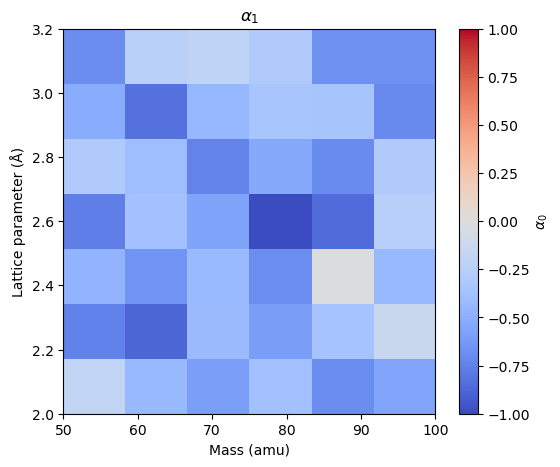

In [18]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="alpha1",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_1$")


plt.colorbar(label=r"$\alpha_0$")

plt.show()

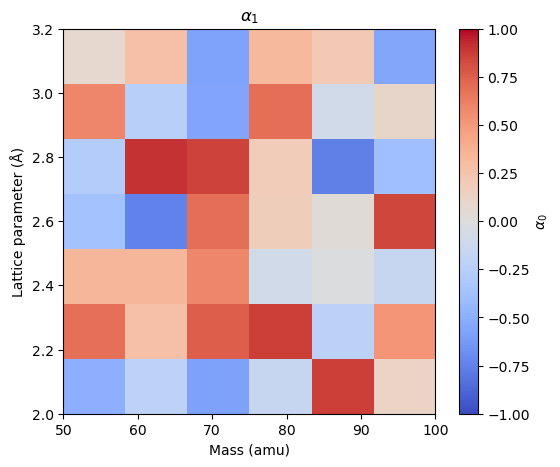

In [19]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="beta1",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_1$")


plt.colorbar(label=r"$\alpha_0$")

plt.show()

In [20]:
cols = [
    "mass",
    "a_val",
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
    "fitness_norm",
]

best_df[cols].corr()

,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm
mass,1.000000e+00,-9.826552e-16,-0.145522,0.097627,-0.016212,0.077324,-0.011727,0.250420
a_val,-9.826552e-16,1.000000e+00,0.066785,-0.012203,-0.112849,-0.042585,-0.013567,0.009897
alpha0,-1.455218e-01,6.678520e-02,1.000000,-0.464252,0.207397,0.070375,-0.405247,-0.064744
alpha1,9.762660e-02,-1.220348e-02,-0.464252,1.000000,-0.070729,0.030030,-0.466632,0.139518
beta1,-1.621229e-02,-1.128490e-01,0.207397,-0.070729,1.000000,0.346267,-0.287189,0.237432
alpha2,7.732419e-02,-4.258521e-02,0.070375,0.030030,0.346267,1.000000,-0.615498,-0.003728
beta2,-1.172715e-02,-1.356719e-02,-0.405247,-0.466632,-0.287189,-0.615498,1.000000,-0.066034
fitness_norm,2.504197e-01,9.896757e-03,-0.064744,0.139518,0.237432,-0.003728,-0.066034,1.000000


<Axes: >

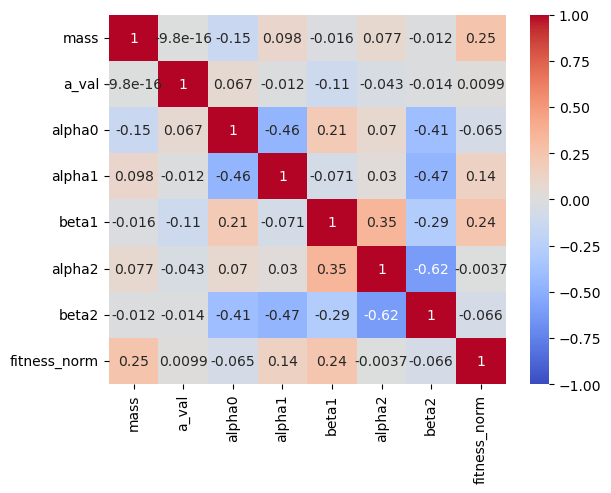

In [21]:
import seaborn as sns

sns.heatmap(best_df[cols].corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm")

In [22]:
X = best_df[
    ["alpha0","alpha1","beta1","alpha2","beta2"]
].values

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fc_cols = [
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
]

X = best_df[fc_cols].values

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [25]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [26]:
print(pca.explained_variance_ratio_)

[0.40437281 0.30194347]


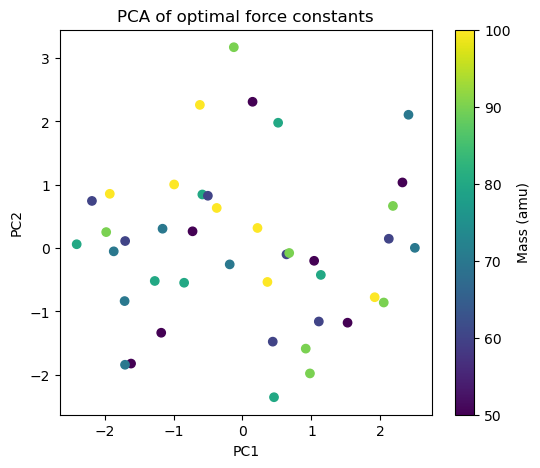

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=best_df["mass"],
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(sc, label="Mass (amu)")

plt.title("PCA of optimal force constants")

plt.show()

In [28]:
c=best_df["a_val"]

In [29]:
c=best_df["fitness_norm"]

In [30]:
loadings = pd.DataFrame(
    pca.components_,
    columns=fc_cols,
    index=["PC1", "PC2"],
)

loadings

,alpha0,alpha1,beta1,alpha2,beta2
PC1,-0.313931,-0.134770,-0.419611,-0.550626,0.635627
PC2,-0.595722,0.752522,-0.187483,0.071743,-0.196286


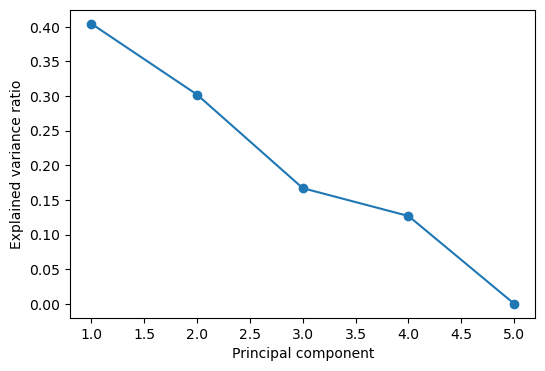

In [31]:
pca_full = PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(fc_cols)+1),
    pca_full.explained_variance_ratio_,
    marker="o",
)

plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")

plt.show()

In [32]:
pca_full = PCA()

pca_full.fit(X_scaled)

print(pca_full.explained_variance_ratio_)

[4.04372810e-01 3.01943468e-01 1.66910880e-01 1.26730032e-01
 4.28095456e-05]


In [33]:
loadings_full = pd.DataFrame(
    pca_full.components_,
    columns=fc_cols,
    index=[f"PC{i+1}" for i in range(len(fc_cols))]
)

loadings_full

,alpha0,alpha1,beta1,alpha2,beta2
PC1,-0.313931,-0.134770,-0.419611,-0.550626,0.635627
PC2,-0.595722,0.752522,-0.187483,0.071743,-0.196286
PC3,-0.535659,-0.182785,0.673513,0.280235,0.384068
PC4,-0.200437,-0.356213,-0.578921,0.703564,0.052781
PC5,0.468462,0.505222,0.002816,0.343701,0.638088


In [34]:
best_df["PC5"] = pca_full.transform(X_scaled)[:,4]

In [35]:
best_df["PC5"].describe()

count    4.200000e+01
mean    -9.388675e-18
std      1.480771e-02
min     -4.578063e-02
25%     -9.311881e-03
50%     -9.062605e-04
75%      5.883883e-03
max      4.812990e-02
Name: PC5, dtype: float64

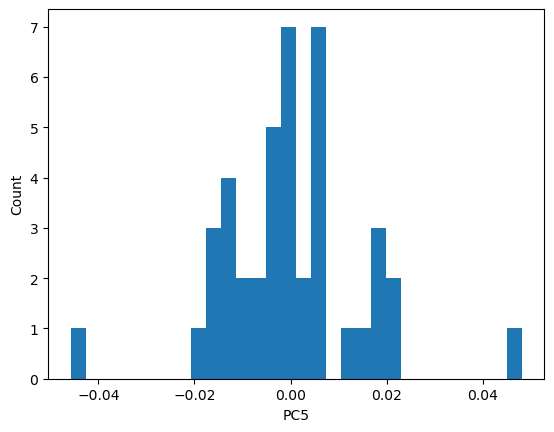

In [36]:
plt.hist(best_df["PC5"], bins=30)
plt.xlabel("PC5")
plt.ylabel("Count")
plt.show()

In [37]:
best_df.loc[best_df["PC5"].abs().idxmax()]

simulation                                                     simulation000411
generation                                                                   83
solution_index                                                               10
rank                                                                          0
mass                                                                       90.0
a_val                                                                       3.0
alpha0                                                                 9.375088
alpha1                                                                -0.343753
beta1                                                                 -0.093077
alpha2                                                                 0.078967
beta2                                                                 -1.655506
fitness                           [1.0, 0.8613463285219063, 0.9165835946967412]
fitness1                                

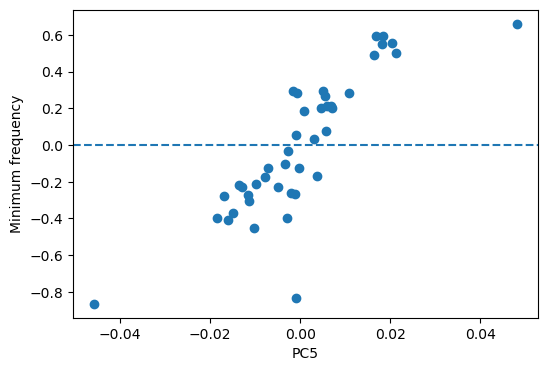

In [38]:
plt.figure(figsize=(6,4))

sc = plt.scatter(
    best_df["PC5"],
    best_df["min_frequency"],
)

plt.xlabel("PC5")
plt.ylabel("Minimum frequency")

plt.axhline(0, linestyle="--")

plt.show()

In [39]:
from scipy.stats import linregress

res = linregress(
    best_df["PC5"],
    best_df["min_frequency"],
)

print(res)

LinregressResult(slope=np.float64(21.484045381953973), intercept=np.float64(-0.004227378947362607), rvalue=np.float64(0.843810091474557), pvalue=np.float64(2.265914386258257e-12), stderr=np.float64(2.1603590150236753), intercept_stderr=np.float64(0.03160685184165829))


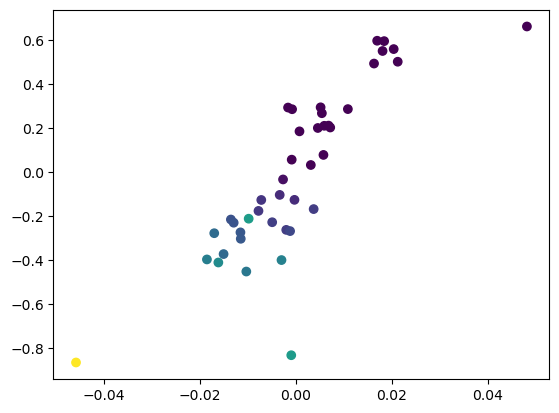

In [40]:
plt.scatter(
    best_df["PC5"],
    best_df["min_frequency"],
    c=best_df["num_imaginary"],
)

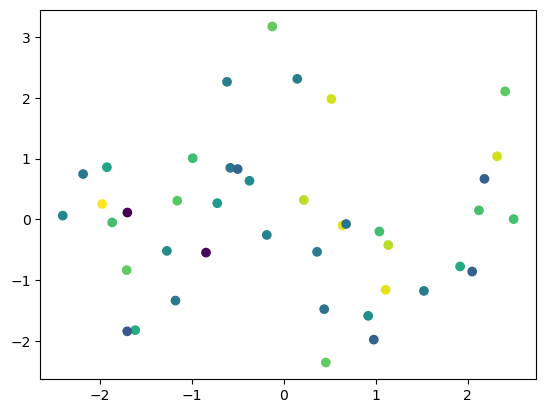

In [41]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=best_df["min_frequency"],
)

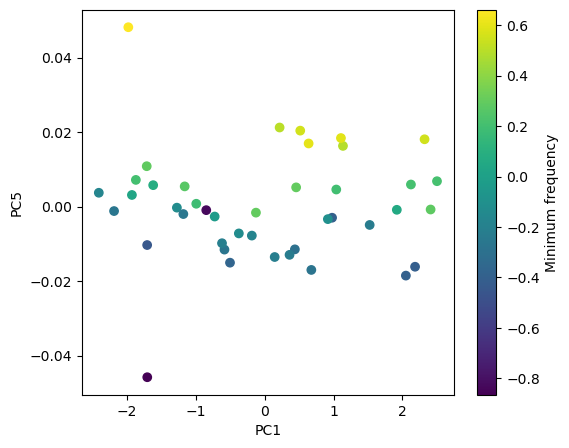

In [42]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,0],
    best_df["PC5"],
    c=best_df["min_frequency"],
)

plt.xlabel("PC1")
plt.ylabel("PC5")

plt.colorbar(sc, label="Minimum frequency")

plt.show()

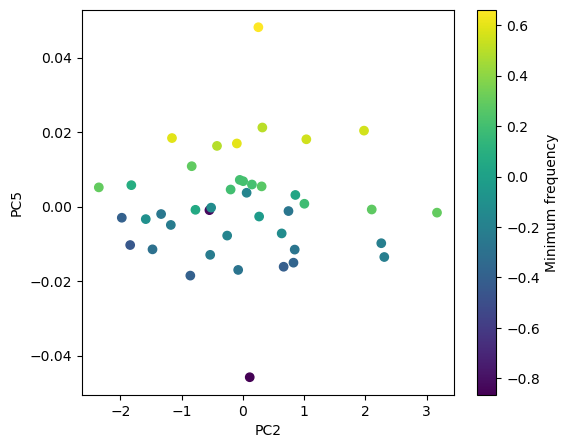

In [43]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,1],
    best_df["PC5"],
    c=best_df["min_frequency"],
)

plt.xlabel("PC2")
plt.ylabel("PC5")

plt.colorbar(sc, label="Minimum frequency")

plt.show()